In [81]:
import torch
import numpy as np
import random
from collections import deque, defaultdict
import heapq

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─── 地圖與參數 ─────────────────────────────────────────
WIDTH, HEIGHT = 21, 11
treasure_list = [(0,6),(3,16),(8,2),(10,2),(10,17)]
walls_coords  = {
    (0,4),(0,5),(0,7),(0,9),(1,1),(1,2),(1,4),(1,9),(1,10),(1,14),(1,18),
    (2,1),(2,3),(2,5),(2,7),(2,8),(2,9),(2,11),(2,13),(2,15),(2,16),(2,17),(2,19),
    (3,2),(3,8),(3,11),(3,17),(4,1),(4,4),(4,6),(4,10),(4,13),(4,16),(4,17),(4,18),(4,20),
    (5,4),(5,5),(5,6),(5,8),(5,9),(5,14),(5,15),(6,1),(6,2),(6,3),(6,6),(6,8),(6,10),(6,15),(6,16),(6,17),(6,19),
    (7,4),(7,6),(7,8),(7,10),(7,11),(7,17),(7,19),(8,1),(8,4),(8,8),(8,10),(8,13),(8,15),(8,18),(8,19),
    (9,1),(9,2),(9,4),(9,6),(9,7),(9,17),(10,1),(10,4),(10,16),(10,19)
}
START, GOAL = (0,0), (20,10)

# 尺度轉換 助教給的牆壁座標與實際地圖對不起來，應 x, y 軸轉換
treasure_list = [(y, x) for x, y in treasure_list]
walls_coords  = {(y, x) for x, y in walls_coords}

# Q-learning 超參數
MAX_EPISODES = 1000
MAX_STEPS    = 1000
EPSILON, EPS_DECAY, EPS_MIN = 0.9, 0.9992, 0.1
ALPHA, GAMMA = 0.9, 0.995

# Prioritized Sweeping
PLANNING_STEPS     = 20
PRIORITY_THRESHOLD = 1e-4
BETA = 0.3

ACTIONS     = ['up','down','left','right']
NUM_ACTIONS = len(ACTIONS)
NUM_MASK    = 1 << len(treasure_list)
NUM_STATES  = WIDTH * HEIGHT * NUM_MASK

# 用 GPU 存 Q 表
Q1 = torch.zeros(NUM_STATES, NUM_ACTIONS, device=device)
Q2 = torch.zeros(NUM_STATES, NUM_ACTIONS, device=device)

Model        = {}
predecessors = defaultdict(list)
priority_q   = []

opposite = {'up':'down','down':'up','left':'right','right':'left'}

def to_index(pos):
    return pos[1] * WIDTH + pos[0]

def encode_state(pos, mask):
    return to_index(pos) * NUM_MASK + mask

def compute_target(pos, act):
    x, y = pos
    if act == 'up':     y = max(0, y-1)
    elif act == 'down': y = min(HEIGHT-1, y+1)
    elif act == 'left': x = max(0, x-1)
    else:               x = min(WIDTH-1, x+1)
    return (x, y)

# 定義計算 potential 的小函數
def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def potential(pos, mask):
    # 找出所有還沒收集的寶藏座標
    remaining = [treasure_list[i] 
                 for i in range(len(treasure_list)) 
                 if not (mask & (1<<i))]
    # 如果都收完了，就只把終點當目標
    if not remaining:
        remaining = [GOAL]
    # 返回負的最小曼哈頓距離
    return -min(manhattan(pos, tgt) for tgt in remaining)

# 最佳成功軌跡 & 最多寶藏軌跡
best_steps, best_score, best_path, best_reason = MAX_STEPS+1, -1, None, None
best_treasure_score, best_treasure_path, best_treasure_reason = -1, None, None

epsilon = EPSILON

for ep in range(1, MAX_EPISODES+1):
    if ep < 200:
        epsilon = max(0.2, epsilon * 0.999)
    elif ep < 600:
        epsilon = max(0.1, epsilon * 0.9993)
    else:
        epsilon = max(0.05, epsilon * 0.995)

    if ep < 300:
        PLANNING_STEPS = 5
    elif ep < 600:
        PLANNING_STEPS = 10
    else:
        PLANNING_STEPS = 20

    recent_positions = deque(maxlen=5)
    pos, mask = START, 0
    s = encode_state(pos, mask)
    path  = [s]
    score = 0
    prev_a = None

    # 新增：全域訪問計數
    visit_count = defaultdict(int)
    visit_count[s] = 1

    stop_reason = "max steps reached"

    for step in range(1, MAX_STEPS+1):
        # 1) ε-greedy + 回頭遮罩（軟）
        if random.random() < epsilon:
            a = random.randrange(NUM_ACTIONS)
        else:
            a = int(torch.argmax(Q1[s] + Q2[s]).item())

        new_pos = compute_target(pos, ACTIONS[a])

        # 撞牆或停留原地 → 懲罰 500 分
        hit_wall = (new_pos in walls_coords or new_pos == pos)
        if hit_wall:
            r = -500
            s2 = s
        else:
            # 2) 計算獎勵 & 更新 mask
            # 先算舊狀態的勢
            phi_s = potential(pos, mask)
            r = -1
            picked = False
            if new_pos in treasure_list:
                i = treasure_list.index(new_pos)
                if not (mask & (1<<i)):
                    mask |= (1<<i)
                    # 最後一個寶藏給更高獎勵
                    reward_for_this_treasure = 10 + 2 * score   # score 已是已收寶藏數
                    r = reward_for_this_treasure
                    score += 1
                    picked = True
            elif new_pos == GOAL:
                r = +100 if mask == (NUM_MASK-1) else -80

            # —— 如果剛撿到寶箱，就清空 recent_positions，允許折返 —— 
            if picked:
                recent_positions.clear()

            # —— 振盪懲罰 —— 
            if not picked and new_pos in recent_positions:
                r -= 20

            # 回頭懲罰：如果這一步正好是走回上一動作的反向
            if prev_a is not None and ACTIONS[a] == opposite[ACTIONS[prev_a]]:
                r -= 25

            # Count-based 新奇獎勵
            visit_count[s2] += 1
            r += 1.0 / np.sqrt(visit_count[s2])

            # 重複訪問懲罰，只有訪問超過 3 次才扣分
            if visit_count[s2] > 2:
                r -= 8 * (visit_count[s2] - 1)

            if picked:
                prev_a = None  # 拾金返身
            # 再算新狀態的勢，並做 shaping 差分
            phi_s2 = potential(new_pos, mask)
            r += BETA * (GAMMA * phi_s2 - phi_s)
            s2 = encode_state(new_pos, mask)

        # 3) Double Q 更新
        if random.random() < 0.5:
            a2 = int(torch.argmax(Q1[s2]).item())
            td = r + GAMMA*Q2[s2,a2] - Q1[s,a]
            Q1[s,a] += ALPHA * td
        else:
            a2 = int(torch.argmax(Q2[s2]).item())
            td = r + GAMMA*Q1[s2,a2] - Q2[s,a]
            Q2[s,a] += ALPHA * td

        # 4) Model & predecessors
        Model[(s,a)] = (r, s2)
        predecessors[s2].append((s,a))

        # 5) push priority
        if abs(td.item()) > PRIORITY_THRESHOLD:
            heapq.heappush(priority_q, (-abs(td.item()), s, a))

        # 6) Prioritized Sweeping
        for _ in range(PLANNING_STEPS):
            if not priority_q: break
            _, sp, ap = heapq.heappop(priority_q)
            rp, sp2 = Model[(sp,ap)]
            if random.random() < 0.5:
                anp = int(torch.argmax(Q1[sp2]).item())
                td2 = rp + GAMMA*Q2[sp2,anp] - Q1[sp,ap]
                Q1[sp,ap] += ALPHA * td2
            else:
                anp = int(torch.argmax(Q2[sp2]).item())
                td2 = rp + GAMMA*Q1[sp2,anp] - Q2[sp,ap]
                Q2[sp,ap] += ALPHA * td2

            for spre, apre in predecessors[sp]:
                rpre, spre2 = Model[(spre,apre)]
                q1max = torch.max(Q1[spre2]).item()
                q2max = torch.max(Q2[spre2]).item()
                qtar  = rpre + GAMMA * max(q1max, q2max)
                qpred = max(Q1[spre,apre].item(), Q2[spre,apre].item())
                if abs(qtar - qpred) > PRIORITY_THRESHOLD:
                    heapq.heappush(priority_q, (-abs(qtar-qpred), spre, apre))

        # 7) 真實移動 & 更新狀態
        if not hit_wall:
            # 把 pos 加入最近 5 步記錄（新的 new_pos 將被記錄在下一行）
            recent_positions.append(pos)
            pos, s = new_pos, s2
            path.append(s2)
            prev_a = a

        # 成功判斷
        if pos == GOAL and mask == (NUM_MASK-1):
            stop_reason = "reached goal with all treasures"
            if step < best_steps:
                best_steps, best_score, best_path, best_reason = step, score, path.copy(), stop_reason
            break

    # 更新「最多寶藏」軌跡
    if score > best_treasure_score:
        best_treasure_score, best_treasure_path, best_treasure_reason = score, path.copy(), stop_reason

    # ε 衰減
    epsilon = max(EPS_MIN, epsilon*EPS_DECAY)
    if ep % 50 == 0 or ep in (1, MAX_EPISODES):
        print(f"Ep{ep:4d} | ε={epsilon:.3f} | best_steps={best_steps} | best_score={best_score}")

    # 清理 Dyna‐planning 緩存
    Model.clear()
    predecessors.clear()
    priority_q.clear()
    recent_positions.clear()

# ─── 最終結果輸出 ─────────────────────────────────────────
if best_path is not None:
    use_path, label, final_score, final_reason = best_path, "（成功）", best_score, best_reason
else:
    use_path, label, final_score, final_reason = best_treasure_path, "（未成功，以寶藏數最多輸出）", best_treasure_score, best_treasure_reason

collected = []
pos, mask = START, 0
for state in use_path:
    idx = state // NUM_MASK
    x, y = idx % WIDTH, idx // WIDTH
    if (x,y) in treasure_list and (x,y) not in collected:
        collected.append((x,y))
    pos = (x,y)

print(f"=== 最終結果 {label} ===")
print(f"停止原因：{final_reason}")
print(f"步數：{len(use_path)-1}")
print(f"寶藏：{final_score}/{len(treasure_list)} -> {collected}")
print(f"最終停留：{pos} (應為 {GOAL})")

Ep   1 | ε=0.898 | best_steps=1001 | best_score=-1
Ep  50 | ε=0.823 | best_steps=1001 | best_score=-1
Ep 100 | ε=0.752 | best_steps=1001 | best_score=-1
Ep 150 | ε=0.687 | best_steps=1001 | best_score=-1
Ep 200 | ε=0.628 | best_steps=819 | best_score=5
Ep 250 | ε=0.583 | best_steps=819 | best_score=5
Ep 300 | ε=0.540 | best_steps=819 | best_score=5
Ep 350 | ε=0.501 | best_steps=819 | best_score=5
Ep 400 | ε=0.465 | best_steps=819 | best_score=5
Ep 450 | ε=0.432 | best_steps=483 | best_score=5
Ep 500 | ε=0.400 | best_steps=483 | best_score=5
Ep 550 | ε=0.371 | best_steps=483 | best_score=5
Ep 600 | ε=0.343 | best_steps=345 | best_score=5
Ep 650 | ε=0.257 | best_steps=345 | best_score=5
Ep 700 | ε=0.192 | best_steps=345 | best_score=5
Ep 750 | ε=0.143 | best_steps=345 | best_score=5
Ep 800 | ε=0.107 | best_steps=345 | best_score=5
Ep 850 | ε=0.100 | best_steps=345 | best_score=5
Ep 900 | ε=0.100 | best_steps=345 | best_score=5
Ep 950 | ε=0.100 | best_steps=345 | best_score=5
Ep1000 | ε=0

In [82]:
coords = []
for s in use_path:
    idx = s // NUM_MASK
    # row ∈ [0, HEIGHT-1], col ∈ [0, WIDTH-1]
    row = idx // WIDTH
    col = idx % WIDTH
    # 恢復成 (x, y) = (col, row)
    coords.append((col, row))

print("完整軌跡：", coords)

完整軌跡： [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 5), (2, 5), (3, 5), (3, 4), (3, 3), (4, 3), (5, 3), (5, 4), (5, 3), (4, 3), (5, 3), (6, 3), (6, 2), (6, 1), (6, 2), (6, 1), (7, 1), (6, 1), (6, 0), (6, 1), (6, 2), (6, 3), (5, 3), (4, 3), (3, 3), (3, 4), (3, 5), (2, 5), (1, 5), (0, 5), (0, 6), (0, 7), (0, 6), (0, 7), (1, 7), (2, 7), (3, 7), (3, 8), (3, 9), (3, 10), (3, 9), (3, 10), (3, 9), (3, 10), (3, 9), (3, 10), (2, 10), (3, 10), (2, 10), (3, 10), (2, 10), (3, 10), (3, 9), (3, 8), (3, 7), (3, 8), (3, 9), (3, 8), (3, 7), (3, 8), (3, 7), (3, 8), (3, 7), (3, 8), (3, 7), (3, 8), (3, 7), (3, 8), (2, 8), (2, 7), (1, 7), (0, 7), (0, 6), (0, 5), (0, 4), (0, 5), (1, 5), (2, 5), (3, 5), (3, 4), (3, 3), (4, 3), (5, 3), (6, 3), (6, 2), (6, 3), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (7, 8), (6, 8), (5, 8), (5, 9), (5, 10), (6, 10), (7, 10), (8, 10), (9, 10), (9, 9), (10, 9), (11, 9), (11, 8), (12, 8), (11, 8), (12, 8), (11, 8), (12, 8), (11, 8), (12, 8), (11, 8), (12, 8), (11, 8), (12, 

c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23542 (\N{CJK UNIFIED IDEOGRAPH-5BF6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 34255 (\N{CJK UNIFIED IDEOGRAPH-85CF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 40670 (\N{CJK UNIFIED IDEOGRAPH-9EDE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Yves\anaconda3\envs\tf-env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32066 (\N{CJK UNIFIED IDEOGRAPH-7D42}) miss

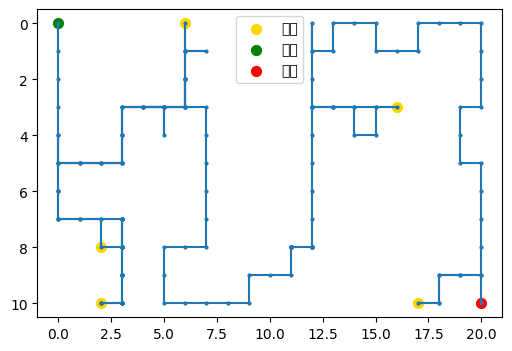

In [83]:
import matplotlib.pyplot as plt

xs, ys = zip(*coords)
plt.figure(figsize=(6,4))
plt.plot(xs, ys, '-o', markersize=2)
# 標注寶藏、起點、終點
tx, ty = zip(*treasure_list)
plt.scatter(tx, ty, c='gold', label='寶藏', s=50)
plt.scatter(START[0], START[1], c='green', label='起點',  s=50)
plt.scatter(GOAL[0],  GOAL[1],  c='red',   label='終點', s=50)
plt.gca().invert_yaxis()  # (0,0) 在左上角
plt.legend()
plt.show()

In [74]:
# 訓練結束後，先把 Q 從 GPU 移回 CPU，再轉換成 numpy
Q1_cpu = Q1.cpu().numpy()
Q2_cpu = Q2.cpu().numpy()

# 存成 .npz
import numpy as np
np.savez("trained_q_tables.npz", Q1=Q1_cpu, Q2=Q2_cpu)

# 或者用 torch 保存為 .pt
import torch
torch.save({"Q1": Q1_cpu, "Q2": Q2_cpu}, "trained_q_tables.pt")

In [75]:
Q1_cpu = Q1.cpu().numpy()
print("Q1:\n", Q1_cpu)
Q2_cpu = Q1.cpu().numpy()
print("Q2:\n", Q2_cpu)

Q1:
 [[-1028.1772    -604.11554  -1021.3362    -607.52246 ]
 [ -771.2431    -266.44653   -736.29083   -294.8404  ]
 [ -573.82263    -37.75719   -509.76816    -36.062843]
 ...
 [ -385.76245   -783.87915   -787.9613    -752.35376 ]
 [ -459.48145   -828.15356   -876.79333   -877.6709  ]
 [    0.           0.           0.           0.      ]]
Q2:
 [[-1028.1772    -604.11554  -1021.3362    -607.52246 ]
 [ -771.2431    -266.44653   -736.29083   -294.8404  ]
 [ -573.82263    -37.75719   -509.76816    -36.062843]
 ...
 [ -385.76245   -783.87915   -787.9613    -752.35376 ]
 [ -459.48145   -828.15356   -876.79333   -877.6709  ]
 [    0.           0.           0.           0.      ]]
